In [1]:
from py_files.setup import *
setup_notebook()

In [2]:
# 0. extraction helper
def code_token(x: pd.Index) -> pd.Series:
    s = pd.Series(x, dtype="string")
    return s.str.extract(r"^\s*([^ ]+)", expand=False)

# 1. extract codes
m_code = code_token(var_groups.mothers)          
s_code = code_token(var_groups.subs)     

# 2. mother letter of sub
s_mother = s_code.str[0]
groups = s_code.groupby(s_mother).apply(list).to_dict()

# `Model implied` $\phi$

**Goal:** Analyse empirical $w_I/w_C$ and find the $\phi$ that make the `Uzawa` yield the same ratio.

I want to get the wage per worker, i.e., I compute:
$$
    \text{ratio} = \frac{w_I}{w_C} \cdot \frac{L_C}{L_I}
$$

**Process:**
1. Estimate empirical ratio.
2. Compute model implied ratio, given $\mu$ per the GG-B condition.
3. Iterate over different $\phi$ until they match.
4. Report the implied $\phi$ for sanity

**Data:**
1. `NABP36` for employee compensation per industry.
2. `RAS307` employees per industry.

*`1. Empirical result`*

In [3]:
# 1. compensation fetch
NABP36 = DstApi('NABP36')
NABP36.tablesummary(language='en')
NABP36.variable_levels('PRISENHED',language='en')

params_e = {
    'table': 'NABP36',
    'format': 'BULK',
    'lang': 'en',
    'variables': [
        {'code': 'PRISENHED'    , 'values': ['V']},     # current
        {'code': 'TRANSAKT'     , 'values': ['D1D']},   # D.1 Compensation of employees
        {'code': 'Tid'          , 'values': ['*']},
        {'code': 'BRANCHE'      , 'values': ['*']},
        ]
}

# clean
df_e_ = NABP36.get_data(params=params_e)
df_e_['INDHOLD'] = pd.to_numeric(df_e_['INDHOLD'], errors='coerce')
df_e = df_e_[['TID','BRANCHE','INDHOLD']]

# format
df_e_slim = df_e[~df_e['BRANCHE'].eq('Total')].copy()
df_e_slim['branche_code'] = code_token(df_e_slim['BRANCHE'])
df_e_slim = df_e_slim.rename(columns={'INDHOLD': 'compensation'})

Table NABP36: 1-2.1.1 Production
and  generation of income (36a2-grouping) by transaction, industry, price unit and time
Last update: 2025-06-30T08:00:00


In [4]:
# 2. hours fetch
NABB36 = DstApi('NABB36')
NABB36.tablesummary(language='en')
NABB36.variable_levels('PRISENHED',language='en')

params_d = {
    'table': 'NABB36',
    'format': 'BULK',
    'lang': 'en',
    'variables': [
        {'code': 'SOCIO'    , 'values': ['SALH_DC']}, # Hours worked for employees (1,000 hours)
        {'code': 'BRANCHE'  , 'values': ['*']},       
        {'code': 'Tid'      , 'values': ['*']},
        ]
}

# clean
df_d_ = NABP36.get_data(params=params_d)
df_d_['INDHOLD'] = pd.to_numeric(df_d_['INDHOLD'], errors='coerce')
df_d = df_d_[['TID','BRANCHE','INDHOLD']]

# format
df_d_slim = df_d[~df_d['BRANCHE'].eq('Total')].copy()
df_d_slim['branche_code'] = code_token(df_d_slim['BRANCHE'])
df_d_slim = df_d_slim.rename(columns={'INDHOLD': 'hours'})

Table NABB36: Employment (36a2-grouping) by socioeconomic status, industry and time
Last update: 2025-06-30T08:00:00

                Error: The table does not seem to contain the requested variable.
                Check the spelling (variable names are case sensitive
                )


In [5]:
# 3. merge slims
df = pd.merge(df_e_slim, df_d_slim, on=['TID', 'BRANCHE', 'branche_code'], how='inner')

# 4. sanity on merge
print(f'Unique in e: {df_e_slim.branche_code.nunique()}')
print(f'Unique in d: {df_d_slim.branche_code.nunique()}')

set(df_e_slim.branche_code.unique()) - set(df_d_slim.branche_code.unique())
set(df_d_slim.branche_code.unique()) - set(df_e_slim.branche_code.unique())

Unique in e: 39
Unique in d: 39


set()

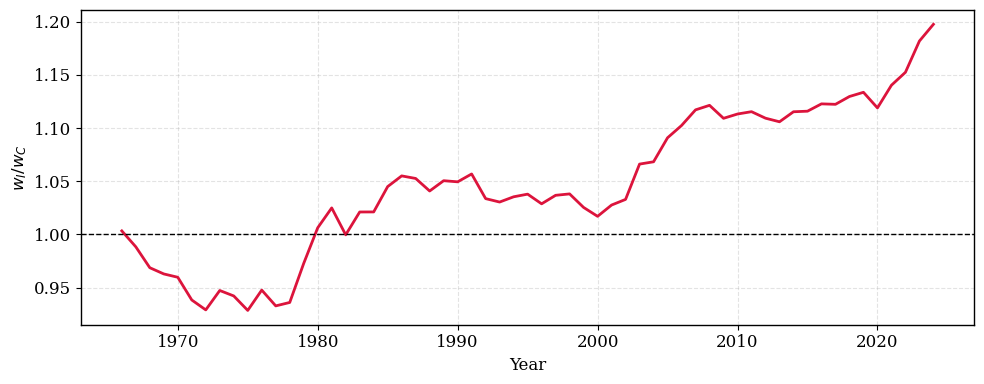

In [6]:
# 4. link to sector, aggregate and calculate compensation per hour
df['type'] = np.select(
    [df['branche_code'].isin(var_groups.consumption_industries),
        df['branche_code'].isin(var_groups.investment_industries)],
    ['C', 'I'],
    default='x'
)

# aggregate
df_agg = df.groupby(['TID', 'type']).agg({'compensation': 'sum', 'hours': 'sum'}).reset_index()
df_agg['w'] = df_agg['compensation'] / df_agg['hours']

# then pivot to get ratio
df_ratio = df_agg.pivot(index='TID', columns='type', values='w')
df_ratio['w_I/w_C'] = df_ratio['I'] / df_ratio['C']

fig, ax = plt.subplots(1, 1, figsize=(10, 4))

ax.plot(df_ratio.index, df_ratio['w_I/w_C'], color='crimson', linewidth=2)
ax.axhline(1, color='black', linewidth=1, linestyle='--')

ax.set_xlabel('Year')
ax.set_ylabel(r'$w_I/w_C$')
ax.grid(ls='--', alpha=0.35)

plt.tight_layout()

*accompany with share of labour force in each!*

In [66]:
# 2. hours fetch
NABB36 = DstApi('NABB36')
NABB36.tablesummary(language='en')
NABB36.variable_levels('SOCIO',language='en')

params_em = {
    'table': 'NABB36',
    'format': 'BULK',
    'lang': 'en',
    'variables': [
        {'code': 'SOCIO'    , 'values': ['SALM_DC']}, # Employees (number)
        {'code': 'BRANCHE'  , 'values': ['*']},        
        {'code': 'Tid'      , 'values': ['*']},
        ]
}

# clean
df_em_ = NABB36.get_data(params=params_em)
df_em_['INDHOLD'] = pd.to_numeric(df_em_['INDHOLD'], errors='coerce')
df_em = df_em_[['TID','BRANCHE','INDHOLD']]

# format
df_em_slim = df_em[~df_em['BRANCHE'].eq('Total')].copy()
df_em_slim['branche_code'] = code_token(df_em_slim['BRANCHE'])
df_em_slim = df_em_slim[~df_em_slim['branche_code'].eq('Of')].copy()

df_em_slim = df_em_slim.rename(columns={'INDHOLD': 'employees'})

# find share per industry
df_em_agg = df_em_slim.groupby(['TID']).agg({'employees': 'sum'}).reset_index()
df_em_agg.columns = ['TID', 'total_employees']

df_em_slim = df_em_slim.merge(df_em_agg, on='TID', how='left')
df_em_slim['L_I/L'] = df_em_slim['employees'] / df_em_slim['total_employees']

# link to industries
df_em_slim['type'] = np.select(
    [df_em_slim['branche_code'].isin(var_groups.consumption_industries),
        df_em_slim['branche_code'].isin(var_groups.investment_industries)],
    ['C', 'I'],
    default='x'
)

# Aggregate to I/C level using weighted average
df_em_agg_ic = (
    df_em_slim
    .groupby(['TID', 'type'])['employees']
    .sum()
    .reset_index()
)

# get total per year
totals = df_em_slim.groupby('TID')['employees'].sum().rename('total')
df_em_agg_ic = df_em_agg_ic.merge(totals, on='TID')
df_em_agg_ic['L_share'] = df_em_agg_ic['employees'] / df_em_agg_ic['total']

df_ratio2 = df_em_agg_ic.pivot(index='TID', columns='type', values='L_share')
df_ratio2['ratio'] = df_ratio2['I'] / df_ratio2['C']

Table NABB36: Employment (36a2-grouping) by socioeconomic status, industry and time
Last update: 2025-06-30T08:00:00


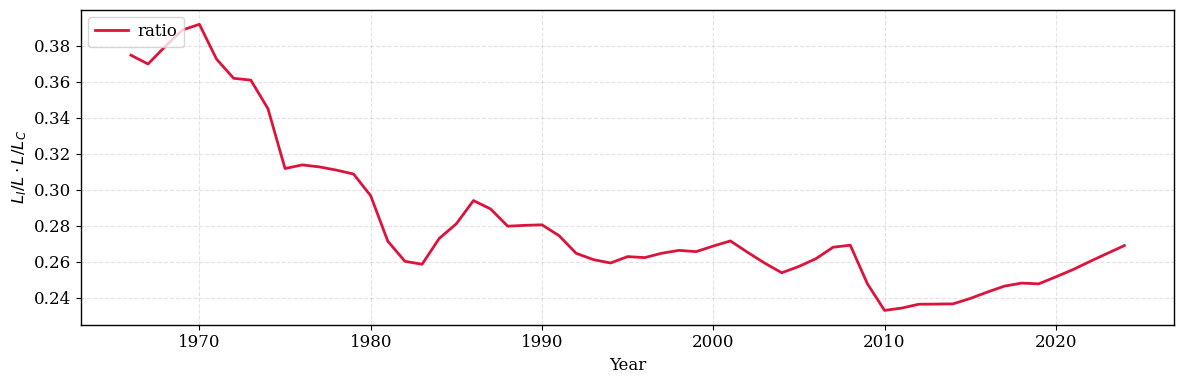

In [71]:
fig, ax = plt.subplots(1, 1, figsize=(12, 4))

# ax.plot(df_ratio2.index, df_ratio2['C'], color='k', linewidth=2)
# ax.plot(df_ratio2.index, df_ratio2['I'], color='crimson', linewidth=2)
ax.plot(df_ratio2.index, df_ratio2['ratio'], color='crimson', linewidth=2)

ax.set_xlabel('Year')
ax.set_ylabel(r'$L_I/L \cdot L/L_C$')
ax.grid(ls='--', alpha=0.35)
# ax.legend(['Consumption', 'Investment'], loc='upper left')
ax.legend(['ratio'], loc='upper left')

plt.tight_layout()